# Which one is a better plan?

You work as an analyst for the telecom operator Megaline. The company offers its clients two prepaid plans, Surf and Ultimate. The commercial department wants to know which of the plans brings in more revenue in order to adjust the advertising budget.

You are going to carry out a preliminary analysis of the plans based on a relatively small client selection. You'll have the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. Your job is to analyze the clients' behavior and determine which prepaid plan brings in more revenue.

## Project Purpose


The purpose is to conduct a preliminary analysis of the data on 500 Megaline clients: who the clients are, where they're from, which plan they use, and the number of calls they made and text messages they sent in 2018. 

In this project, the goal is to analyze clients' behavior and determine which prepaid plan brings in more revenue. 

#### Project Steps

- Gather the datasets
- Prepare the data for analysis
- Analyze the data for information and insights on customer behavior
- Test hypotheses on average revenue from users of the calling plans



## Initialization

In [1]:
# Loading all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st


## Load data

In [2]:
# Load the data files into different DataFrames

df_calls = pd.read_csv('/datasets/megaline_calls.csv')

df_internet = pd.read_csv('/datasets/megaline_internet.csv')

df_messages = pd.read_csv('/datasets/megaline_messages.csv')

df_plans = pd.read_csv('/datasets/megaline_plans.csv')

df_users = pd.read_csv('/datasets/megaline_users.csv')

## Prepare the data

## Plans

In [3]:
# Print the general/summary information about the plans' DataFrame
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [5]:
# Print a sample of data for plans

df_plans.sample()


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
1,1000,30720,3000,70,7,0.01,0.01,ultimate


Comparing the two plans: 

For the Surf plan,
- the customers gets 15.36 GB of data, more than the 15 GB described. 

For the Ultimate plan,
- each customer gets 30.72 GB of data, more than the 30 GB described.

###  Fix data

In [6]:
#Check to see if the data has been preprocessed, expecting no missing values or duplicates.


df_plans.isna().sum()

messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64

In [7]:
df_plans.duplicated().sum()

0

### Enrich data

I thought it might be helpful to reorder the columns so that the plan name is in front. 

In [8]:
df_plans_columns = list(df_plans.columns.values)
display(df_plans_columns)

['messages_included',
 'mb_per_month_included',
 'minutes_included',
 'usd_monthly_pay',
 'usd_per_gb',
 'usd_per_message',
 'usd_per_minute',
 'plan_name']

In [9]:
df_plans = df_plans[['plan_name', 'usd_monthly_pay', 'minutes_included', 'messages_included',
 'mb_per_month_included', 'usd_per_minute', 'usd_per_message', 
 'usd_per_gb',
 ]]

In [10]:
df_plans.head()

,plan_name,usd_monthly_pay,minutes_included,messages_included,mb_per_month_included,usd_per_minute,usd_per_message,usd_per_gb
0,surf,20,500,50,15360,0.03,0.03,10
1,ultimate,70,3000,1000,30720,0.01,0.01,7


## Users

In [11]:
# Print the general/summary information about the users' DataFrame

df_users.info() # Seeing 500 users as expected.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [12]:
# Print a sample of data for users

df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [13]:
df_users.sample()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
248,1248,Leigha,Dawson,35,"Nashville-Davidson–Murfreesboro–Franklin, TN MSA",2018-11-01,surf,NaN


In [14]:
#Check to see if the data has been preprocessed, expecting no missing values or duplicates.


df_users.isna().sum()

user_id         0
first_name      0
last_name       0
age             0
city            0
reg_date        0
plan            0
churn_date    466
dtype: int64

In [15]:
df_users.duplicated().sum()

0

From the description of the data, the churn_date column has missing or NaN values. According to the notes, this means that they were subscribed when this data was extracted. 

Looking at the table:
- I'm not clear on whether I should be turning the city column to a category, and if that's true, what would be the value in making this change. 

- There appears to be a misspelling for USA in the city column.

- The reg_date shows the subscription sign-up date, this is a string.

### Fix Data

In [16]:
# It appears that USA is misspelled as MSA. 

In [17]:
#remove 'MVS' from strings in city column and replace with 'USA'
df_users['city'] = df_users['city'].str.replace('MSA', 'USA')


In [18]:
#checking the change
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA USA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA USA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV USA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK USA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA USA",2018-05-23,surf,NaN


In [19]:
#Change the reg_date column from a string to a datetime object.

df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d')


In [20]:
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


### Enrich Data

In [21]:
unique_city = df_users['city'].unique()

display(unique_city)

array(['Atlanta-Sandy Springs-Roswell, GA USA',
       'Seattle-Tacoma-Bellevue, WA USA',
       'Las Vegas-Henderson-Paradise, NV USA', 'Tulsa, OK USA',
       'Dallas-Fort Worth-Arlington, TX USA',
       'San Francisco-Oakland-Berkeley, CA USA',
       'Grand Rapids-Kentwood, MI USA',
       'Orlando-Kissimmee-Sanford, FL USA',
       'San Jose-Sunnyvale-Santa Clara, CA USA',
       'Cleveland-Elyria, OH USA',
       'Chicago-Naperville-Elgin, IL-IN-WI USA', 'Knoxville, TN USA',
       'New York-Newark-Jersey City, NY-NJ-PA USA', 'Pittsburgh, PA USA',
       'Fresno, CA USA',
       'Washington-Arlington-Alexandria, DC-VA-MD-WV USA',
       'Indianapolis-Carmel-Anderson, IN USA', 'Jacksonville, FL USA',
       'Los Angeles-Long Beach-Anaheim, CA USA',
       'Omaha-Council Bluffs, NE-IA USA',
       'Houston-The Woodlands-Sugar Land, TX USA',
       'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD USA',
       'Tampa-St. Petersburg-Clearwater, FL USA',
       'Birmingham-Hoover, AL USA'

In [22]:
# The USA substring is in all the cities...  so, let's extract it and put it in another column

In [23]:
df_users['city'] = df_users['city'].str.slice(0, -4)

In [24]:
df_users['country'] = 'USA'

In [25]:
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,country
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA",2018-12-24,ultimate,NaN,USA
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA",2018-08-13,surf,NaN,USA
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV",2018-10-21,surf,NaN,USA
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK",2018-01-28,surf,NaN,USA
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA",2018-05-23,surf,NaN,USA


## Calls

In [26]:
# Print the general/summary information about the calls' DataFrame

df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [27]:
# Print a sample of data for calls
df_calls.head()


,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


Looking at the calls table: 

- The data description mentions that all calls are rounded up to minutes, yet we see a float for the values in the duration column.

- The call_date column is a string object, so I'll change that to datetime.

In [28]:
#Check to see if the data has been preprocessed, expecting no missing values or duplicates.


df_calls.isna().sum()

id           0
user_id      0
call_date    0
duration     0
dtype: int64

In [29]:
df_calls.duplicated().sum()

0

### Fix data

In [30]:
#df_calls['duration'] = df_calls['duration'].round().astype(int)

df_calls['duration'] = df_calls['duration'].apply(np.ceil)

In [31]:
df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
3,1000_309,1000,2018-12-28,6.0
4,1000_380,1000,2018-12-30,5.0


In [32]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


### Enrich data

In [33]:
#Change the call_date column from a string to a datetime object.

df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

In [34]:
#rename date column so we have the same column name for processing later

df_calls.rename(columns = {'call_date':'date'}, inplace = True)

In [35]:
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   id        137735 non-null  object        
 1   user_id   137735 non-null  int64         
 2   date      137735 non-null  datetime64[ns]
 3   duration  137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


## Messages

In [36]:
# Print the general/summary information about the messages' DataFrame

df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [37]:
# Print a sample of data for messages

df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


Here it looks like we see records of individual messages. Each record shows the user id, the date the message was sent, and an id for each message.

Looking at the table: 
- The message_date column is a string object, so I'll change that to datetime.

In [38]:
#Check to see if the data has been preprocessed, expecting no missing values or duplicates.


df_messages.isna().sum()

id              0
user_id         0
message_date    0
dtype: int64

In [39]:
df_messages.duplicated().sum()


0

### Fix data

In [40]:
#Change the message_date column from a string to a datetime object.

df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

In [41]:
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


### Enrich data

In [42]:
#rename date column so we have the same column name for processing later

df_messages.rename(columns = {'message_date':'date', 'id':'message_id'}, inplace = True)

In [43]:
df_messages.head()

,message_id,user_id,date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


## Internet

In [44]:
# Print the general/summary information about the internet DataFrame

df_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [45]:
# Print a sample of data for the internet traffic
df_internet.head()


,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


Looking at the table: 

- We see in mb_used the float for this info. For web traffic, individual sessions are not rounded up, so I'll leave this float. 

- The session_date column is a string object, so I'll change that to datetime.

In [46]:
#Check to see if the data has been preprocessed, expecting no missing values or duplicates.


df_internet.isna().sum()

id              0
user_id         0
session_date    0
mb_used         0
dtype: int64

In [47]:
df_internet.duplicated().sum()

0

### Fix data

In [48]:
#Change the session_date column from a string to a datetime object.

df_internet['session_date'] = pd.to_datetime(df_internet['session_date'], format='%Y-%m-%d')

### Enrich data

In [49]:
#rename date column so we have the same column name for processing later

df_internet.rename(columns = {'session_date':'date'}, inplace = True)

## Study plan conditions

**Details to note:**

Megaline rounds seconds up to minutes, and megabytes to gigabytes. 

**For calls,** each individual call is rounded up: even if the call lasted just one second, it will be counted as one minute. (Note: I already adjusted the data to accommodate this condition.)

**For web traffic**, individual web sessions are not rounded up. Instead, the total for the month is rounded up. If someone uses 1025 megabytes this month, they will be charged for 2 gigabytes.


In [50]:
# Print out the plan conditions and make sure they are clear for you

# The details of each plan
display(df_plans.loc[0])


plan_name                 surf
usd_monthly_pay             20
minutes_included           500
messages_included           50
mb_per_month_included    15360
usd_per_minute            0.03
usd_per_message           0.03
usd_per_gb                  10
Name: 0, dtype: object

In [51]:
display(df_plans.loc[1])

plan_name                ultimate
usd_monthly_pay                70
minutes_included             3000
messages_included            1000
mb_per_month_included       30720
usd_per_minute               0.01
usd_per_message              0.01
usd_per_gb                      7
Name: 1, dtype: object

## Aggregate data per user


In [52]:
# Calculate the number of calls made by each user per month. Save the result. 
df_calls.head() # Review some of the data again


,id,user_id,date,duration
0,1000_93,1000,2018-12-27,9.0
1,1000_145,1000,2018-12-27,14.0
2,1000_247,1000,2018-12-27,15.0
3,1000_309,1000,2018-12-28,6.0
4,1000_380,1000,2018-12-30,5.0


In [53]:
#Group the data by user_id and the month, then count the number of calls, sum the number of minutes. 

In [54]:
df_calls['month'] = df_calls.date.dt.month

In [55]:
calls_per_month = df_calls.pivot_table(index=['user_id', 'month'], values='duration', aggfunc='count')

##### I'm not clear on how to rename the columns for the pivot table when I use multiple aggfunctions, so I ended up creating separate and merging. 

In [56]:
#Calculate the mins per month

mins_per_month = df_calls.pivot_table(index=['user_id', 'month'], values='duration', aggfunc='sum')

In [57]:
# Calculate the number of messages sent by each user per month. Save the result.
df_messages.head()


df_messages['month'] = df_messages.date.dt.month

In [58]:
df_messages.head()

,message_id,user_id,date,month
0,1000_125,1000,2018-12-27,12
1,1000_160,1000,2018-12-31,12
2,1000_223,1000,2018-12-31,12
3,1000_251,1000,2018-12-27,12
4,1000_255,1000,2018-12-26,12


In [59]:
messages_per_month = df_messages.pivot_table(index=['user_id', 'month'], values='message_id', aggfunc='count')

In [60]:
#Group the data by user_id and the month, then count the number of messages.

messages_per_month.head(30)

message_id
user_id month            
1000    12             11
1001    8              30
        9              44
        10             53
        11             36
        12             44
1002    10             15
        11             32
        12             41
1003    12             50
1004    5               7
        6              18
        7              26
        8              25
        9              21
        10             24
        11             25
        12             31
1005    12             11
1006    11             15
        12            139
1007    8              51
        9              47
        10             59
        11             48
        12             50
1008    10             21
        11             37
        12             26
1011    6              21

In [61]:
# Calculate the volume of internet traffic used by each user per month. Save the result.


df_internet.head() #Review the data again


,id,user_id,date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [62]:

df_internet['month'] = df_internet.date.dt.month

In [63]:
df_internet.head()

,id,user_id,date,mb_used,month
0,1000_13,1000,2018-12-29,89.86,12
1,1000_204,1000,2018-12-31,0.00,12
2,1000_379,1000,2018-12-28,660.40,12
3,1000_413,1000,2018-12-26,270.99,12
4,1000_442,1000,2018-12-27,880.22,12


In [64]:
#This time I'm looking for a total, so I'll use sum

volume_per_month = df_internet.pivot_table(index=['user_id', 'month'], values='mb_used', aggfunc='sum')

In [65]:
volume_per_month.head(30)


mb_used
user_id month          
1000    12      1901.47
1001    8       6919.15
        9      13314.82
        10     22330.49
        11     18504.30
        12     19369.18
1002    10      6552.01
        11     19345.08
        12     14396.24
1003    12     27044.14
1004    5       6547.21
        6      20672.82
        7      24516.62
        8      27981.74
        9      18852.72
        10     14541.63
        11     21850.78
        12     21389.29
1005    12     17140.17
1006    11      2068.37
        12     32118.82
1007    8      24439.88
        9      28123.95
        10     37885.63
        11     24334.00
        12     29069.28
1008    10     17106.99
        11     23676.72
        12     14689.33
1009    5      20389.40

At the end of the month, the total data for the month is converted from mb to gb and rounded up.

In [66]:
#Convert the monthly data from mb to gb 
volume_per_month['gb_used'] = volume_per_month['mb_used'] * .00124

In [67]:
volume_per_month.head(30) #check on things

mb_used    gb_used
user_id month                     
1000    12      1901.47   2.357823
1001    8       6919.15   8.579746
        9      13314.82  16.510377
        10     22330.49  27.689808
        11     18504.30  22.945332
        12     19369.18  24.017783
1002    10      6552.01   8.124492
        11     19345.08  23.987899
        12     14396.24  17.851338
1003    12     27044.14  33.534734
1004    5       6547.21   8.118540
        6      20672.82  25.634297
        7      24516.62  30.400609
        8      27981.74  34.697358
        9      18852.72  23.377373
        10     14541.63  18.031621
        11     21850.78  27.094967
        12     21389.29  26.522720
1005    12     17140.17  21.253811
1006    11      2068.37   2.564779
        12     32118.82  39.827337
1007    8      24439.88  30.305451
        9      28123.95  34.873698
        10     37885.63  46.978181
        11     24334.00  30.174160
        12     29069.28  36.045907
1008    10     17106.99  21.212668
        11     23676.72  29.359133
        12     14689.33  18.214769
1009    5      20389.40  25.282856

In [68]:
#Round up the monthly data for each month to the next gb
volume_per_month['gb_used'] = volume_per_month['gb_used'].apply(np.ceil)

In [69]:
volume_per_month.head(30) #Check our work

mb_used  gb_used
user_id month                   
1000    12      1901.47      3.0
1001    8       6919.15      9.0
        9      13314.82     17.0
        10     22330.49     28.0
        11     18504.30     23.0
        12     19369.18     25.0
1002    10      6552.01      9.0
        11     19345.08     24.0
        12     14396.24     18.0
1003    12     27044.14     34.0
1004    5       6547.21      9.0
        6      20672.82     26.0
        7      24516.62     31.0
        8      27981.74     35.0
        9      18852.72     24.0
        10     14541.63     19.0
        11     21850.78     28.0
        12     21389.29     27.0
1005    12     17140.17     22.0
1006    11      2068.37      3.0
        12     32118.82     40.0
1007    8      24439.88     31.0
        9      28123.95     35.0
        10     37885.63     47.0
        11     24334.00     31.0
        12     29069.28     37.0
1008    10     17106.99     22.0
        11     23676.72     30.0
        12     14689.33     19.0
1009    5      20389.40     26.0

### Putting the information together:

In [70]:
# Merge the data for calls, minutes, messages, internet based on user_id and month

In [71]:
# Merge calls + minutes

calls_mins = calls_per_month.merge(mins_per_month, on=['user_id', 'month'], how='outer')

calls_mins.head()



duration_x  duration_y
user_id month                        
1000    12             16       124.0
1001    8              27       182.0
        9              49       315.0
        10             65       393.0
        11             64       426.0

In [72]:
# Merge to add messages

calls_messages = calls_mins.merge(messages_per_month, on=['user_id', 'month'], how='outer')

calls_messages.head()

duration_x  duration_y  message_id
user_id month                                    
1000    12           16.0       124.0        11.0
1001    8            27.0       182.0        30.0
        9            49.0       315.0        44.0
        10           65.0       393.0        53.0
        11           64.0       426.0        36.0

In [73]:
# Merge to add internet data

df_merged = calls_messages.merge(volume_per_month, on=['user_id', 'month'], how='outer')

df_merged.head(30)



duration_x  duration_y  message_id   mb_used  gb_used
user_id month                                                       
1000    12           16.0       124.0        11.0   1901.47      3.0
1001    8            27.0       182.0        30.0   6919.15      9.0
        9            49.0       315.0        44.0  13314.82     17.0
        10           65.0       393.0        53.0  22330.49     28.0
        11           64.0       426.0        36.0  18504.30     23.0
        12           56.0       412.0        44.0  19369.18     25.0
1002    10           11.0        59.0        15.0   6552.01      9.0
        11           55.0       386.0        32.0  19345.08     24.0
        12           47.0       384.0        41.0  14396.24     18.0
1003    12          149.0      1104.0        50.0  27044.14     34.0
1004    5            21.0       193.0         7.0   6547.21      9.0
        6            44.0       275.0        18.0  20672.82     26.0
        7            49.0       381.0        26.0  24516.62     31.0
        8            49.0       354.0        25.0  27981.74     35.0
        9            42.0       301.0        21.0  18852.72     24.0
        10           61.0       365.0        24.0  14541.63     19.0
        11           54.0       476.0        25.0  21850.78     28.0
        12           50.0       427.0        31.0  21389.29     27.0
1005    12           59.0       496.0        11.0  17140.17     22.0
1006    11            2.0        10.0        15.0   2068.37      3.0
        12            9.0        59.0       139.0  32118.82     40.0
1007    8            70.0       456.0        51.0  24439.88     31.0
        9            63.0       399.0        47.0  28123.95     35.0
        10           80.0       645.0        59.0  37885.63     47.0
        11           80.0       524.0        48.0  24334.00     31.0
        12           87.0       617.0        50.0  29069.28     37.0
1008    10           71.0       476.0        21.0  17106.99     22.0
        11           63.0       446.0        37.0  23676.72     30.0
        12           85.0       634.0        26.0  14689.33     19.0
1009    5            71.0       534.0         NaN  20389.40     26.0

In [74]:
df_merged.rename(columns={'duration_x': 'calls_per_month', 'duration_y': 'mins_per_month', 'message_id': 'messages_per_month'}, inplace=True)

In [75]:
df_merged.head()

calls_per_month  mins_per_month  messages_per_month   mb_used  \
user_id month                                                                  
1000    12                16.0           124.0                11.0   1901.47   
1001    8                 27.0           182.0                30.0   6919.15   
        9                 49.0           315.0                44.0  13314.82   
        10                65.0           393.0                53.0  22330.49   
        11                64.0           426.0                36.0  18504.30   

               gb_used  
user_id month           
1000    12         3.0  
1001    8          9.0  
        9         17.0  
        10        28.0  
        11        23.0

In [76]:
df_users.head() #Refreshing our memory of this table

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,country
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA",2018-12-24,ultimate,NaN,USA
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA",2018-08-13,surf,NaN,USA
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV",2018-10-21,surf,NaN,USA
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK",2018-01-28,surf,NaN,USA
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA",2018-05-23,surf,NaN,USA


In [77]:
# Add the plan information

#Merging eliminateed the month column from df_merged and I couldn't figure out how to keep it there
#customer_plans = df_merged.merge(df_users, how='left', on='user_id')

#Using join because I couldn't get merge to keep the month column. 
customer_plans = df_merged.join(
    df_users.set_index('user_id'),
    on=['user_id'],
    how="inner",
    lsuffix="_x",
    rsuffix="_y",)

#print to check our work
customer_plans.reset_index()

,user_id,month,calls_per_month,mins_per_month,messages_per_month,mb_used,gb_used,first_name,last_name,age,city,reg_date,plan,churn_date,country
0,1000,12,16.0,124.0,11.0,1901.47,3.0,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA",2018-12-24,ultimate,NaN,USA
1,1001,8,27.0,182.0,30.0,6919.15,9.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA",2018-08-13,surf,NaN,USA
2,1001,9,49.0,315.0,44.0,13314.82,17.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA",2018-08-13,surf,NaN,USA
3,1001,10,65.0,393.0,53.0,22330.49,28.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA",2018-08-13,surf,NaN,USA
4,1001,11,64.0,426.0,36.0,18504.30,23.0,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA",2018-08-13,surf,NaN,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288,1204,12,NaN,NaN,78.0,36730.05,46.0,Sherly,Levy,44,"Chicago-Naperville-Elgin, IL-IN-WI",2018-08-20,ultimate,NaN,USA
2289,1349,10,NaN,NaN,76.0,13093.55,17.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH",2018-10-01,surf,NaN,USA
2290,1349,11,NaN,NaN,72.0,17128.26,22.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH",2018-10-01,surf,NaN,USA
2291,1349,12,NaN,NaN,61.0,13039.91,17.0,Florentina,Diaz,69,"Boston-Cambridge-Newton, MA-NH",2018-10-01,surf,NaN,USA


In [78]:
#fill in our NaNs with 0

customer_plans.fillna({'calls_per_month':0, 'mins_per_month':0, 'messages_per_month': 0, 'mb_used': 0 }, inplace=True)

## Calculate monthly revenue


In [79]:
# Calculate the monthly revenue for each user per month

#rates 
surf_plan = 20
ultimate_plan = 70

#will create a function and use apply() to loop through each row in customer_plans
   

#set some base values
surf_surcharge_mins = 0
surf_surcharge_texts = 0
surf_surcharge_data = 0 

ult_surcharge_mins = 0
ult_surcharge_texts = 0
ult_surcharge_data = 0

In [80]:
def calc_charge(row):
    plan = row['plan']
    mins_per_month = row['mins_per_month']
    messages_per_month = row['messages_per_month']
    mb_used = row['mb_used']
    
    surf_surcharge_mins = 0
    surf_surcharge_texts = 0
    surf_surcharge_data = 0
    
    ult_surcharge_mins = 0
    ult_surcharge_texts = 0
    ult_surcharge_data = 0
    
    if plan == 'surf':
        plan_rate = surf_plan
        
        #calculate the surcharge, if any
        if mins_per_month > 500:
            surf_surcharge_mins = ((mins_per_month - 500) * 0.03)
        if messages_per_month > 50:
            surf_surcharge_texts = ((messages_per_month - 50) * 0.03) 
        if mb_used > 15360:
            surf_surcharge_data = (((mb_used - 15360) * 0.001) * 10)
        
        surcharge = surf_surcharge_mins + surf_surcharge_texts + surf_surcharge_data
        
        #calculate the monthly charge
        revenue = plan_rate + surcharge
        return revenue
    
    elif plan == 'ultimate':
        plan_rate = ultimate_plan
    
        #calculate the surcharge, if any
         
        if mins_per_month > 3000:
            ult_surcharge_mins = ((mins_per_month - 3000) * 0.01)
        if messages_per_month > 1000: 
            ult_surcharge_texts = ((messages_per_month - 1000) * 0.01)
        if mb_used > 30720:
            ult_surcharge_data = (((mb_used - 30720) * 0.001) * 7)
        
        surcharge = ult_surcharge_mins + ult_surcharge_texts + ult_surcharge_data
        
        #calculate the monthly revenue
        revenue = plan_rate + surcharge
        return revenue
    


In [81]:
#create a new column for the monthly charge and will use apply with multiple columns as input
customer_plans['monthly_revenue'] = customer_plans.apply(calc_charge, axis=1)


In [82]:
#check our results, look good
customer_plans.tail(30)

calls_per_month  mins_per_month  messages_per_month   mb_used  \
user_id month                                                                  
1080    8                  0.0             0.0                31.0  20519.74   
        9                  0.0             0.0                64.0  25499.72   
        10                 0.0             0.0                59.0  30161.57   
        11                 0.0             0.0                50.0  33559.88   
        12                 0.0             0.0                61.0  24543.42   
1089    12                 0.0             0.0                27.0  16597.91   
1121    11                 0.0             0.0                 1.0   1236.65   
        12                 0.0             0.0                97.0  66863.89   
1131    5                  0.0             0.0                18.0   6468.11   
        6                  0.0             0.0                27.0  14637.04   
        7                  0.0             0.0                28.0  16564.01   
        8                  0.0             0.0                33.0  12271.78   
        9                  0.0             0.0                26.0  15594.75   
        10                 0.0             0.0                31.0  21292.61   
        11                 0.0             0.0                20.0  13697.04   
        12                 0.0             0.0                33.0  15212.42   
1137    10                 0.0             0.0                48.0   7002.91   
        11                 0.0             0.0                64.0   3084.69   
        12                 0.0             0.0                56.0   6745.66   
1194    8                  0.0             0.0                10.0   5704.93   
        9                  0.0             0.0                76.0  37298.02   
        10                 0.0             0.0                88.0  31538.39   
        11                 0.0             0.0                62.0  42866.10   
        12                 0.0             0.0                56.0  31088.49   
1204    11                 0.0             0.0                42.0  21346.95   
        12                 0.0             0.0                78.0  36730.05   
1349    10                 0.0             0.0                76.0  13093.55   
        11                 0.0             0.0                72.0  17128.26   
        12                 0.0             0.0                61.0  13039.91   
1108    12                 0.0             0.0                 0.0    233.17   

               gb_used  first_name last_name  age  \
user_id month                                       
1080    8         26.0        Neal     Mcgee   45   
        9         32.0        Neal     Mcgee   45   
        10        38.0        Neal     Mcgee   45   
        11        42.0        Neal     Mcgee   45   
        12        31.0        Neal     Mcgee   45   
1089    12        21.0      Malena    Kelley   70   
1121    11         2.0   Kathaleen    Albert   34   
        12        83.0   Kathaleen    Albert   34   
1131    5          9.0       Shane  Morrison   60   
        6         19.0       Shane  Morrison   60   
        7         21.0       Shane  Morrison   60   
        8         16.0       Shane  Morrison   60   
        9         20.0       Shane  Morrison   60   
        10        27.0       Shane  Morrison   60   
        11        17.0       Shane  Morrison   60   
        12        19.0       Shane  Morrison   60   
1137    10         9.0     Allegra   Hopkins   20   
        11         4.0     Allegra   Hopkins   20   
        12         9.0     Allegra   Hopkins   20   
1194    8          8.0      Robert    Mclean   40   
        9         47.0      Robert    Mclean   40   
        10        40.0      Robert    Mclean   40   
        11        54.0      Robert    Mclean   40   
        12        39.0      Robert    Mclean   40   
1204    11        27.0      Sherly      Levy   44   
        12        46.0 

## Study user behavior

### Calls

In [83]:
# Comparing the average duration of calls per each plan per each distinct month.
    
    
# Average duration of calls per person 
customer_plans['avg_call_duration'] = customer_plans['mins_per_month'] / customer_plans['calls_per_month']


In [84]:
customer_plans.head(20) #check our work

calls_per_month  mins_per_month  messages_per_month   mb_used  \
user_id month                                                                  
1000    12                16.0           124.0                11.0   1901.47   
1001    8                 27.0           182.0                30.0   6919.15   
        9                 49.0           315.0                44.0  13314.82   
        10                65.0           393.0                53.0  22330.49   
        11                64.0           426.0                36.0  18504.30   
        12                56.0           412.0                44.0  19369.18   
1002    10                11.0            59.0                15.0   6552.01   
        11                55.0           386.0                32.0  19345.08   
        12                47.0           384.0                41.0  14396.24   
1003    12               149.0          1104.0                50.0  27044.14   
1004    5                 21.0           193.0                 7.0   6547.21   
        6                 44.0           275.0                18.0  20672.82   
        7                 49.0           381.0                26.0  24516.62   
        8                 49.0           354.0                25.0  27981.74   
        9                 42.0           301.0                21.0  18852.72   
        10                61.0           365.0                24.0  14541.63   
        11                54.0           476.0                25.0  21850.78   
        12                50.0           427.0                31.0  21389.29   
1005    12                59.0           496.0                11.0  17140.17   
1006    11                 2.0            10.0                15.0   2068.37   

               gb_used first_name  last_name  age  \
user_id month                                       
1000    12         3.0   Anamaria      Bauer   45   
1001    8          9.0     Mickey  Wilkerson   28   
        9         17.0     Mickey  Wilkerson   28   
        10        28.0     Mickey  Wilkerson   28   
        11        23.0     Mickey  Wilkerson   28   
        12        25.0     Mickey  Wilkerson   28   
1002    10         9.0     Carlee    Hoffman   36   
        11        24.0     Carlee    Hoffman   36   
        12        18.0     Carlee    Hoffman   36   
1003    12        34.0   Reynaldo    Jenkins   52   
1004    5          9.0    Leonila   Thompson   40   
        6         26.0    Leonila   Thompson   40   
        7         31.0    Leonila   Thompson   40   
        8         35.0    Leonila   Thompson   40   
        9         24.0    Leonila   Thompson   40   
        10        19.0    Leonila   Thompson   40   
        11        28.0    Leonila   Thompson   40   
        12        27.0    Leonila   Thompson   40   
1005    12        22.0      Livia    Shields   31   
1006    11         3.0     Jesusa   Bradford   73   

                                             city   reg_date      plan  \
user_id month                                                            
1000    12      Atlanta-Sandy Springs-Roswell, GA 2018-12-24  ultimate   
1001    8             Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        9             Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        10            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        11            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        12            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
1002    10       Las Vegas-Henderson-Paradise, NV 2018-10-21      surf   
        11       Las Vegas-Henderson-Paradise, NV 2018-10-21      surf   
        12       Las Vegas-Henderson-Paradise, NV 2018-10-21      surf   
1003    12                              Tulsa, OK 2018-01-28      surf   
1004    5             Seattle-Tacoma-Bellevue, WA 2018-05-23      surf   
        6             Seattle-Tacoma-Bellevue, WA 2018-05-23      surf   
        7             Seattle-Tacoma-Bellevue, WA 2

In [85]:

# A pivot table returns a dataframe and I thought it might be easier to read than groupby() 
avg_call_duration = customer_plans.pivot_table(index='month',
                                               columns='plan',
                                               values='avg_call_duration',
                                               aggfunc='mean')



In [86]:
avg_call_duration # Taking a look at the results 

plan,surf,ultimate
month,,
1,6.642857,6.201915
2,6.814628,7.062303
3,7.199957,6.393757
4,7.040349,7.215266
5,7.182627,7.121973
6,7.215501,7.110516
7,7.027745,7.324718
8,7.127926,7.018966
9,7.127642,7.117788


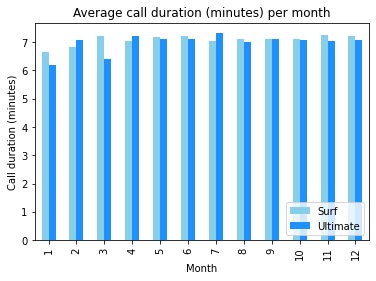

In [87]:
#Visualizing the data

avg_call_duration.plot(title="Average call duration (minutes) per month", 
                       kind='bar',
                       xlabel="Month",
                       color= ['skyblue', 'dodgerblue'],
                       ylabel='Call duration (minutes)'
                      )

plt.legend(['Surf', 'Ultimate'], loc='lower right')


plt.show()

Regardless of plan, or month, most customers make calls that are about 6 minutes long. Interesting!

In [88]:
# Compare the number of minutes users of each plan require each month. Plot a histogram.

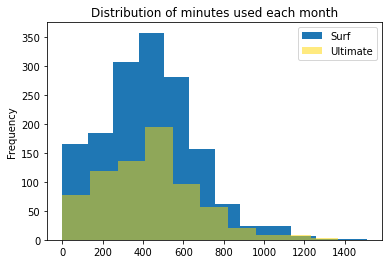

In [89]:
#Remembering that histograms expect numerical data

surf_monthly_mins = customer_plans[customer_plans['plan'] == 'surf']['mins_per_month']
ult_monthly_mins = customer_plans[customer_plans['plan'] == 'ultimate']['mins_per_month']


surf_monthly_mins.plot.hist(title="Distribution of minutes used each month", bins=12)
ult_monthly_mins.plot.hist(color='gold', alpha=0.5)

plt.legend(['Surf', 'Ultimate'])

plt.show()






We're seeing a confirmation that most of the customers are on the Surf plan. 

The distribution here skews to the left, so on both plans, most customers on average use 500 minutes, or less, per month. 

There are also a large number of Surf customers who go over their minutes. Is this an opportunity for the business?

In [90]:
# Taking a closer look at the differences between customers on each plan


surf_plans = customer_plans[customer_plans['plan'] == 'surf']
surf_plans.describe()

,calls_per_month,mins_per_month,messages_per_month,mb_used,gb_used,age,monthly_revenue,avg_call_duration
count,1573.000000,1573.000000,1573.000000,1573.000000,1558.000000,1573.000000,1573.000000,1545.000000
mean,59.811825,428.749523,31.159568,16558.283490,21.236200,44.379530,58.527695,7.158130
std,32.017989,234.453150,33.566717,8013.513327,9.770753,16.646535,55.127406,1.107936
min,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,20.000000,0.000000
25%,39.000000,272.000000,3.000000,11986.520000,16.000000,29.000000,20.000000,6.577586
50%,60.000000,425.000000,24.000000,16829.310000,21.000000,45.000000,37.643700,7.150000
75%,79.000000,576.000000,47.000000,20999.610000,27.000000,59.000000,78.491500,7.697674
max,205.000000,1510.000000,266.000000,70931.590000,88.000000,75.000000,596.085900,19.000000


In [91]:
ult_plans = customer_plans[customer_plans['plan'] == 'ultimate']
ult_plans.describe()

,calls_per_month,mins_per_month,messages_per_month,mb_used,gb_used,age,monthly_revenue,avg_call_duration
count,720.000000,720.000000,720.000000,720.000000,719.000000,720.000000,720.000000,713.000000
mean,60.626389,430.450000,37.551389,17214.699694,21.867872,47.719444,72.166866,7.078557
std,33.242994,240.508762,34.767179,7851.897435,9.705155,16.804088,11.027300,0.956804
min,0.000000,0.000000,0.000000,0.000000,1.000000,18.000000,70.000000,0.000000
25%,36.000000,260.000000,7.000000,12666.955000,16.000000,34.000000,70.000000,6.583333
50%,61.000000,424.000000,30.000000,16858.340000,21.000000,48.500000,70.000000,7.083333
75%,80.000000,565.250000,61.000000,21014.527500,27.000000,64.000000,70.000000,7.662500
max,191.000000,1369.000000,166.000000,46595.330000,58.000000,75.000000,181.127310,11.200000


I think it might be helpful to have the standard deviation for both to make comparisons later, so I'll calculate that too. 

In [92]:
ult_monthly_call_std = ult_plans['avg_call_duration']

ult_monthly_call_std.std().round(2)

0.96

In [93]:
surf_monthly_call_std = surf_plans['avg_call_duration']

surf_monthly_call_std.std().round(2)

1.11

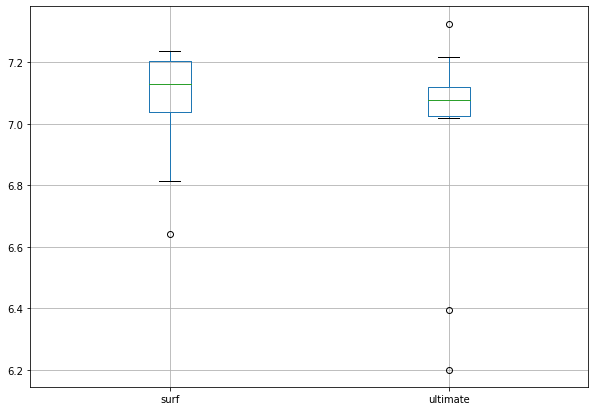

In [94]:
# Plot a boxplot to visualize the distribution of the monthly call duration


# Create our plot
avg_call_duration.boxplot(column=['surf', 'ultimate'], figsize=(10, 7))


plt.show()

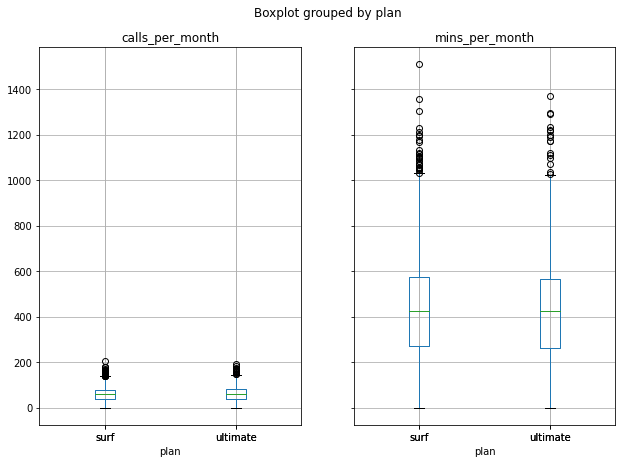

In [95]:
# Let's look at a boxplot of all the call times info to get a better sense of things
customer_plans.boxplot(column=['calls_per_month', 'mins_per_month'], by='plan', figsize=(10, 7))


plt.show()

The users on both plans tend to make calls of the same length and the same number of calls per month. 

### Messages

In [96]:
# Compare the number of messages users of each plan tend to send each month

#remind ourselves about the data
customer_plans.head()

calls_per_month  mins_per_month  messages_per_month   mb_used  \
user_id month                                                                  
1000    12                16.0           124.0                11.0   1901.47   
1001    8                 27.0           182.0                30.0   6919.15   
        9                 49.0           315.0                44.0  13314.82   
        10                65.0           393.0                53.0  22330.49   
        11                64.0           426.0                36.0  18504.30   

               gb_used first_name  last_name  age  \
user_id month                                       
1000    12         3.0   Anamaria      Bauer   45   
1001    8          9.0     Mickey  Wilkerson   28   
        9         17.0     Mickey  Wilkerson   28   
        10        28.0     Mickey  Wilkerson   28   
        11        23.0     Mickey  Wilkerson   28   

                                            city   reg_date      plan  \
user_id month                                                           
1000    12     Atlanta-Sandy Springs-Roswell, GA 2018-12-24  ultimate   
1001    8            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        9            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        10           Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        11           Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   

              churn_date country  monthly_revenue  avg_call_duration  
user_id month                                                         
1000    12           NaN     USA          70.0000           7.750000  
1001    8            NaN     USA          20.0000           6.740741  
        9            NaN     USA          20.0000           6.428571  
        10           NaN     USA          89.7949           6.046154  
        11           NaN     USA          51.4430           6.656250

In [97]:
# a pivot table returns a dataframe and I thought it might be easier to read than groupby() 
avg_messages = customer_plans.pivot_table(index='month',
                                          columns='plan',
                                          values='messages_per_month',
                                          aggfunc='mean')




In [98]:
avg_messages

plan,surf,ultimate
month,,
1,10.500000,15.500000
2,12.000000,21.571429
3,15.260870,20.250000
4,17.400000,22.047619
5,24.012987,32.103448
6,25.298969,29.340426
7,27.033058,32.830508
8,28.777778,38.478873
9,30.762887,37.895349


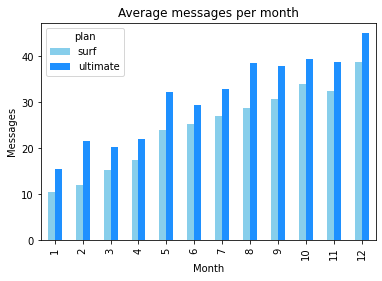

In [99]:
#Create a bar chart to compare the data
avg_messages.plot(title="Average messages per month", 
                       kind='bar',
                       xlabel="Month",
                       color= ['skyblue', 'dodgerblue'],
                       ylabel='Messages')

plt.show()

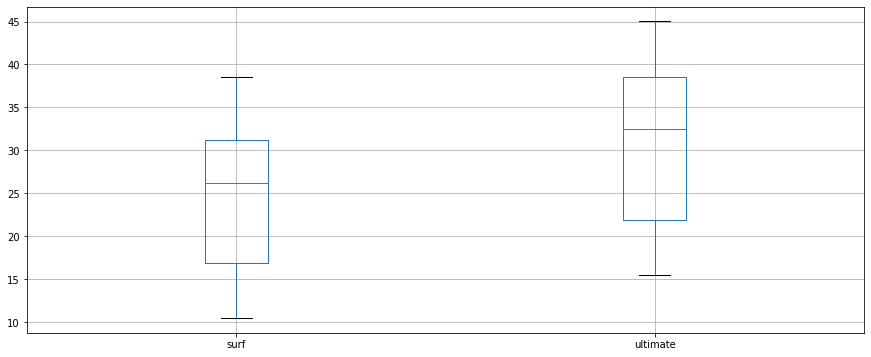

In [100]:
#Create a boxplot to compare the plans against message usage

avg_messages.boxplot(column=['surf', 'ultimate'], figsize=(15,6))

plt.show()

When it comes to messaging, users on the Ultimate consistently send more messages per month. 

### Internet

In [101]:
# Compare the amount of internet traffic consumed by users per plan

In [102]:

#remind ourselves about the data
customer_plans.head()

calls_per_month  mins_per_month  messages_per_month   mb_used  \
user_id month                                                                  
1000    12                16.0           124.0                11.0   1901.47   
1001    8                 27.0           182.0                30.0   6919.15   
        9                 49.0           315.0                44.0  13314.82   
        10                65.0           393.0                53.0  22330.49   
        11                64.0           426.0                36.0  18504.30   

               gb_used first_name  last_name  age  \
user_id month                                       
1000    12         3.0   Anamaria      Bauer   45   
1001    8          9.0     Mickey  Wilkerson   28   
        9         17.0     Mickey  Wilkerson   28   
        10        28.0     Mickey  Wilkerson   28   
        11        23.0     Mickey  Wilkerson   28   

                                            city   reg_date      plan  \
user_id month                                                           
1000    12     Atlanta-Sandy Springs-Roswell, GA 2018-12-24  ultimate   
1001    8            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        9            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        10           Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        11           Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   

              churn_date country  monthly_revenue  avg_call_duration  
user_id month                                                         
1000    12           NaN     USA          70.0000           7.750000  
1001    8            NaN     USA          20.0000           6.740741  
        9            NaN     USA          20.0000           6.428571  
        10           NaN     USA          89.7949           6.046154  
        11           NaN     USA          51.4430           6.656250

In [103]:
customer_plans['gb_used'] = customer_plans['mb_used'] * .001 

In [104]:
avg_data = customer_plans.pivot_table(index='month',
                                          columns='plan',
                                          values='gb_used',
                                          aggfunc='mean')

avg_data


plan,surf,ultimate
month,,
1,4.874860,6.918093
2,12.178843,17.128809
3,13.345440,18.321518
4,11.984203,16.121655
5,13.936355,16.624482
6,15.301529,15.337921
7,16.783601,16.344744
8,16.795331,17.814720
9,16.591431,16.969870


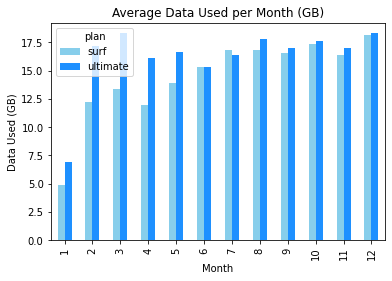

In [105]:
avg_data.plot(title="Average Data Used per Month (GB)", 
                       kind='bar',
                       xlabel="Month",
                       color= ['skyblue', 'dodgerblue'],
                       ylabel='Data Used (GB)')

plt.show()

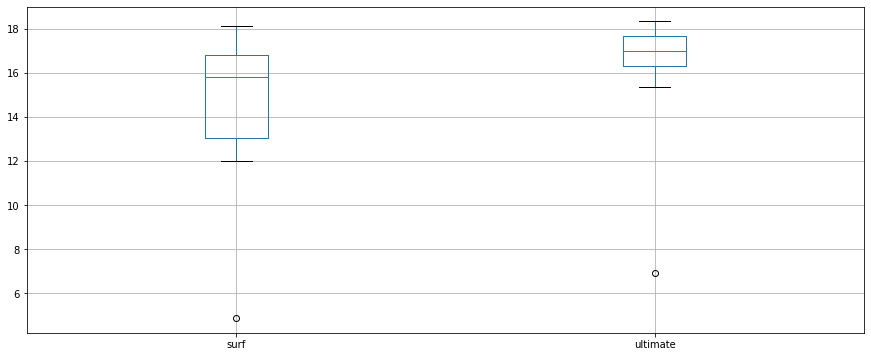

In [106]:

avg_data.boxplot(column=['surf', 'ultimate'], figsize=(15,6))

plt.show()

And when it comes to internet traffic, users on the Ultimate plan, use more data. 

## Revenue

In [107]:
customer_plans.head()

calls_per_month  mins_per_month  messages_per_month   mb_used  \
user_id month                                                                  
1000    12                16.0           124.0                11.0   1901.47   
1001    8                 27.0           182.0                30.0   6919.15   
        9                 49.0           315.0                44.0  13314.82   
        10                65.0           393.0                53.0  22330.49   
        11                64.0           426.0                36.0  18504.30   

                gb_used first_name  last_name  age  \
user_id month                                        
1000    12      1.90147   Anamaria      Bauer   45   
1001    8       6.91915     Mickey  Wilkerson   28   
        9      13.31482     Mickey  Wilkerson   28   
        10     22.33049     Mickey  Wilkerson   28   
        11     18.50430     Mickey  Wilkerson   28   

                                            city   reg_date      plan  \
user_id month                                                           
1000    12     Atlanta-Sandy Springs-Roswell, GA 2018-12-24  ultimate   
1001    8            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        9            Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        10           Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   
        11           Seattle-Tacoma-Bellevue, WA 2018-08-13      surf   

              churn_date country  monthly_revenue  avg_call_duration  
user_id month                                                         
1000    12           NaN     USA          70.0000           7.750000  
1001    8            NaN     USA          20.0000           6.740741  
        9            NaN     USA          20.0000           6.428571  
        10           NaN     USA          89.7949           6.046154  
        11           NaN     USA          51.4430           6.656250

In [108]:
#Calculate the mean for both plans

surf_plans['monthly_revenue'].mean()

58.52769465988557

In [109]:
ult_plans['monthly_revenue'].mean()

72.16686555555556

In [110]:
#Total revenue between plans
surf_plans['monthly_revenue'].sum()

92064.0637

In [111]:
ult_plans['monthly_revenue'].sum()

51960.1432

In [112]:
#Create some descriptive statistics by month


plan_revenue = customer_plans.pivot_table(index='month', columns='plan', values='monthly_revenue', aggfunc=['sum', 'count', 'mean'])

plan_revenue

sum              count                mean           
plan         surf     ultimate  surf ultimate       surf   ultimate
month                                                              
1         40.0000    280.00000     2        4  20.000000  70.000000
2        300.9044    490.00000     9        7  33.433822  70.000000
3       1018.4854    881.68640    23       12  44.281974  73.473867
4       1973.1766   1529.59569    50       21  39.463532  72.837890
5       3566.2111   2045.31481    77       29  46.314430  70.528097
6       4544.8946   3361.08409    97       47  46.854584  71.512427
7       7322.6898   4241.79462   121       59  60.518098  71.894824
8      10035.7332   5164.85417   162       71  61.948970  72.744425
9      10874.4044   6179.59923   194       86  56.053631  71.855805
10     14926.3533   7647.04031   237      106  62.980394  72.141890
11     15878.5174   9098.23334   283      127  56.107835  71.639633
12     21582.6935  11040.94054   318      151  67.870105  73.118812

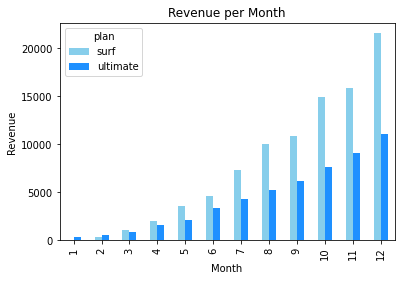

In [113]:
#Bar chart to compare plan revenue over time
plan_revenue['sum'].plot(title="Revenue per Month", 
                       kind='bar',
                       xlabel="Month",
                       color= ['skyblue', 'dodgerblue'],
                      ylabel='Revenue')

plt.show()

<AxesSubplot:>

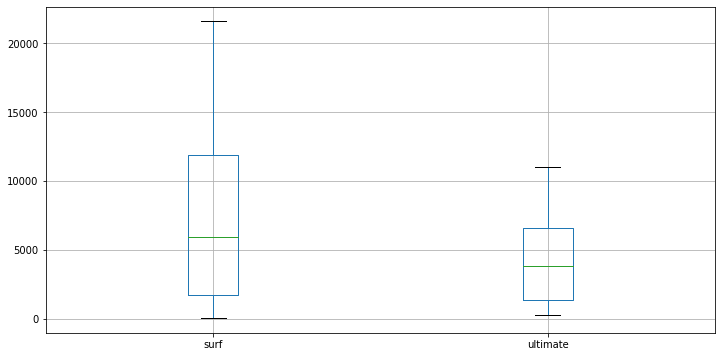

In [114]:
#Boxplot to show more information

#Comparing total monthly revenue by plan

plan_revenue['sum'].boxplot(figsize=(12,6), grid=True)

<AxesSubplot:>

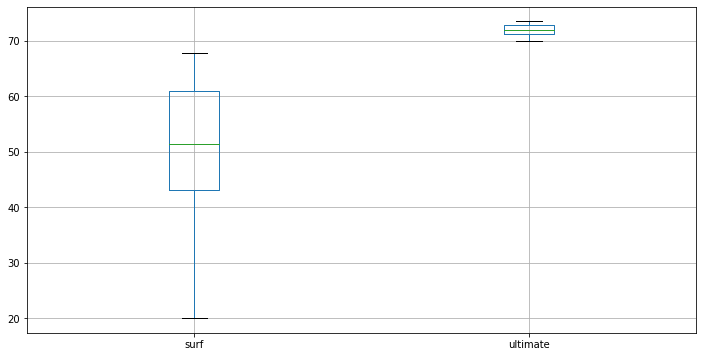

In [115]:
#Comparing average monthly revenue by plan

plan_revenue['mean'].boxplot(figsize=(12,6), grid=True)

By December, the Surf plan becomes exceedingly the more popular plan and the higher performing of the two.

The Surf plan generates almost double the revenue of the Ultimate plan for the year and after two months, the monthly revenue for the Surf plan exceeds the Ultimate plan. 

While the average monthly revenue per person is lower with the Surf plan, there are more customers on this plan and so the total monthly revenue for the Surf plan is higher than the Ultimate plan.



## Test statistical hypotheses

### Does the average revenue from users of the plans differ?

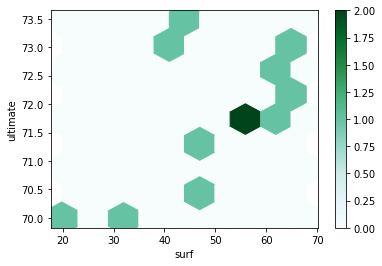

In [116]:
# Creating an visual to see if the average revenue from users of Ultimate and Surf calling plans differs
dist = plan_revenue['mean'].plot(kind='hexbin', x='surf', y='ultimate', gridsize=8, sharex=False)



Testing if the average revenue from users of the Ultimate and Surf calling plans differs. 

Hypotheses used for this test:

H0 = "The average monthly revenue of the two independent plans DOES NOT differ."


H1 = "The average monthly revenue of the two independent plans DOES differ."

In [117]:
#data to work with for revenue
surf_monthly_revenue = surf_plans['monthly_revenue']
ult_monthly_revenue = ult_plans['monthly_revenue']

In [118]:
#Check to see if the var is the same
len(surf_monthly_revenue)

1573

In [119]:
len(ult_monthly_revenue)

720

In [120]:
np.var(surf_monthly_revenue)

3037.098930528172

In [121]:
np.var(ult_monthly_revenue)

121.43245530606276

In [122]:

## Testing the null hypothesis  
H0 = "The average monthly revenue of the two independent plans DOES NOT differ."

alpha = 0.05  # critical statistical significance level (95% confidence)

t_stat, pvalue = st.ttest_ind(surf_monthly_revenue, ult_monthly_revenue, equal_var = False) 
# ttest_ind because these are two different sets of users


print('p-value: ', pvalue)

if pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis") 


p-value:  1.43612414634657e-20
We reject the null hypothesis


In [123]:
## Testing the alternative hypothesis  
H1 = "The average monthly revenue of the two independent plans DOES differ."


alpha = 0.05  # critical statistical significance level (95% confidence)

results = st.ttest_ind(surf_monthly_revenue, ult_monthly_revenue, equal_var = False)

print('p-value: ', results.pvalue)


if results.pvalue > alpha:
    print("We reject the alternative hypothesis")
else:
    print("We can't reject/ we support the alternative hypothesis") 

p-value:  1.43612414634657e-20
We can't reject/ we support the alternative hypothesis


With our hypotheses, we're saying that if the p-value is greater than 0.05, we have a significant difference in average monthly revenue. 

### Is the average revenue for users in the NY-NJ area different than the rest of the USA?

Testing if the average revenue from users in the NY-NJ area differs from other regions of the USA

Hypotheses used for this test:

H0 = "The average monthly revenue from users in the NY-NJ area is different from that of the users from the other regions."

H1 = "The average monthly revenue for NY-NJ is not different from that of users in other areas."

In [124]:
# Testing the hypothesis that the average revenue from users in the NY-NJ area is different from that of the users from the other regions.

# Gather the user information for people from NY-NJ area
customer_plans['city'].unique()

array(['Atlanta-Sandy Springs-Roswell, GA', 'Seattle-Tacoma-Bellevue, WA',
       'Las Vegas-Henderson-Paradise, NV', 'Tulsa, OK',
       'Dallas-Fort Worth-Arlington, TX',
       'San Francisco-Oakland-Berkeley, CA', 'Grand Rapids-Kentwood, MI',
       'Orlando-Kissimmee-Sanford, FL',
       'San Jose-Sunnyvale-Santa Clara, CA', 'Cleveland-Elyria, OH',
       'Chicago-Naperville-Elgin, IL-IN-WI', 'Knoxville, TN',
       'New York-Newark-Jersey City, NY-NJ-PA', 'Pittsburgh, PA',
       'Fresno, CA', 'Washington-Arlington-Alexandria, DC-VA-MD-WV',
       'Indianapolis-Carmel-Anderson, IN', 'Jacksonville, FL',
       'Los Angeles-Long Beach-Anaheim, CA',
       'Omaha-Council Bluffs, NE-IA',
       'Houston-The Woodlands-Sugar Land, TX',
       'Philadelphia-Camden-Wilmington, PA-NJ-DE-MD',
       'Tampa-St. Petersburg-Clearwater, FL', 'Birmingham-Hoover, AL',
       'Oklahoma City, OK', 'Charlotte-Concord-Gastonia, NC-SC',
       'Denver-Aurora-Lakewood, CO',
       'Nashville-Davidson–

In [125]:
nynj_plans = customer_plans[customer_plans['city'] == 'New York-Newark-Jersey City, NY-NJ-PA']['monthly_revenue']

other_plans = customer_plans[~(customer_plans['city'] == 'New York-Newark-Jersey City, NY-NJ-PA')]['monthly_revenue']


In [126]:
len(nynj_plans) #checking to see if we have samples of the same size

377

In [127]:
len(other_plans)

1916

In [128]:
nynj_plans.mean() #gathering some general information

58.16265676392574

In [129]:
other_plans.mean()

63.72488794363257

In [130]:
np.var(nynj_plans) #checking the variance

1855.7717292403015

In [131]:
np.var(other_plans)

2216.7528745194068

In [132]:
## Testing the null hypothesis  
H0 = "The average monthly revenue from users in the NY-NJ area is different from that of the users from the other regions."

alpha = 0.05  # critical statistical significance level (95% confidence)

t_stat, pvalue = st.ttest_ind(nynj_plans, other_plans, equal_var = False) 
# ttest_ind because these are two different sets of users


print('p-value: ', pvalue)

if pvalue < alpha:
    print("We reject the null hypothesis")
else:
    print("We can't reject the null hypothesis") 

p-value:  0.024618428288988532
We reject the null hypothesis


In [133]:
## Testing the alternative hypothesis  
H1 = "The average monthly revenue for NY-NJ is not different from that of users in other areas."


alpha = 0.05  # critical statistical significance level (95% confidence)

results = st.ttest_ind(nynj_plans, other_plans, equal_var = False)

print('p-value: ', results.pvalue)


if results.pvalue > alpha:
    print("We reject the alternative hypothesis")
else:
    print("We can't reject the H1 hypothesis/ we support the alternative hypothesis") 

p-value:  0.024618428288988532
We can't reject the H1 hypothesis/ we support the alternative hypothesis


The p-value tells us that though the average amounts for ny and nj are different, it's still probable that the average monthly revenue is the same.

## General conclusion



The Surf prepaid plan brings in more revenue. 

We looked at the customer data between the Ultimate and Surf plans for calls, messages, data usage; and then explored the revenue calculations between plans. 

We further explored if there is a significant difference between the monthly revenue of each plan and also for differences in revenue for users in the NY-NJ area. 

In testing whether there is a significant difference between the average monthly revenue of the plans, we confirmed that there is a significant difference between plans. 

In testing whether there is a significant difference between the average monthly revenue of users in NY-NJ vs everywhere else in the USA, there is not. 

Our conclusion is that while users of the Ultimate plan send more messages and use more data, the Surf plan has far more users and generates a higher monthly revenue, and the Surf plan is likely to continue to do so.
